In [1]:
# Importing Modules
import pandas as pd
import numpy as np
from src.utils.smiles2morganfp import MorganFP
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import clone
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from scipy import stats

In [2]:
######################## DATA-1 ##################################
# Loading ESOL data
esol_train_data = pd.read_csv("data/train/ESOL.csv")
esol_test_data = pd.read_csv("data/test/ESOL.csv")

# Generate ESOL FP
esol_train_fp = MorganFP(esol_train_data["smiles"], bits=1024)
esol_train_fp["smiles"] = esol_train_fp.index
esol_train_fp = esol_train_fp.merge(esol_train_data, on="smiles")
esol_test_fp = MorganFP(esol_test_data["smiles"], bits=1024)
esol_test_fp["smiles"] = esol_test_fp.index
esol_test_fp = esol_test_fp.merge(esol_test_data, on="smiles")

######################## DATA-2 ##################################
# Loading RT data
rt_train_data = pd.read_csv("data/train/RT.csv")
rt_test_data = pd.read_csv("data/test/RT.csv")

# Generate RT FP
rt_train_fp = MorganFP(rt_train_data["smiles"], bits=1024)
rt_train_fp["smiles"] = rt_train_fp.index
rt_train_fp = rt_train_fp.merge(rt_train_data, on="smiles")
rt_test_fp = MorganFP(rt_test_data["smiles"], bits=1024)
rt_test_fp["smiles"] = rt_test_fp.index
rt_test_fp = rt_test_fp.merge(rt_test_data, on="smiles")

######################## DATA-3 ##################################
# Loading Lipophilicity data
lipophilicity_train_data = pd.read_csv("data/train/Lipophilicity.csv")
lipophilicity_test_data = pd.read_csv("data/test/Lipophilicity.csv")

# Generate lipophilicity FP
lipophilicity_train_fp = MorganFP(lipophilicity_train_data["smiles"], bits=1024)
lipophilicity_train_fp["smiles"] = lipophilicity_train_fp.index
lipophilicity_train_fp = lipophilicity_train_fp.merge(lipophilicity_train_data, on="smiles")
lipophilicity_test_fp = MorganFP(lipophilicity_test_data["smiles"], bits=1024)
lipophilicity_test_fp["smiles"] = lipophilicity_test_fp.index
lipophilicity_test_fp = lipophilicity_test_fp.merge(lipophilicity_test_data, on="smiles")

######################## DATA-4 ##################################
# Loading B3DB data
b3db_train_data = pd.read_csv("data/train/B3DB.csv")
b3db_test_data = pd.read_csv("data/test/B3DB.csv")

# Generate B3DB FP
b3db_train_fp = MorganFP(b3db_train_data["smiles"], bits=1024)
b3db_train_fp["smiles"] = b3db_train_fp.index
b3db_train_fp = b3db_train_fp.merge(b3db_train_data, on="smiles")
b3db_test_fp = MorganFP(b3db_test_data["smiles"], bits=1024)
b3db_test_fp["smiles"] = b3db_test_fp.index
b3db_test_fp = b3db_test_fp.merge(b3db_test_data, on="smiles")

######################## DATA-5 ##################################
# Loading freesolv data
freesolv_train_data = pd.read_csv("data/train/FreeSolv.csv")
freesolv_test_data = pd.read_csv("data/test/FreeSolv.csv")

# Generate freesolv FP
freesolv_train_fp = MorganFP(freesolv_train_data["smiles"], bits=1024)
freesolv_train_fp["smiles"] = freesolv_train_fp.index
freesolv_train_fp = freesolv_train_fp.merge(freesolv_train_data, on="smiles")
freesolv_test_fp = MorganFP(freesolv_test_data["smiles"], bits=1024)
freesolv_test_fp["smiles"] = freesolv_test_fp.index
freesolv_test_fp = freesolv_test_fp.merge(freesolv_test_data, on="smiles")

In [3]:
datasets_baseline_error = {"ESOL":[0.53, "SVM"],
            "Lipophilicity":[0.55, "SVM"],
            "RT":[70.40, "RF"],
            "B3DB":[0.56, "SVM"],
            "FreeSolv":[1.02, "SVM"]}

def smiles2features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return [0]*11 
    
    return [
        Descriptors.MolWt(mol),            # Size
        Descriptors.RingCount(mol),        # Ring counts
        Lipinski.NumHDonors(mol),          # H-Bonding
        Lipinski.NumHAcceptors(mol),       # H-Bonding
        mol.GetNumAtoms(),                 # Scale
        mol.GetNumBonds(),                 # Scale
    ]

In [4]:
def RunML(model_template, train_data, test_data, dataName, modelName, threshold):
    X_test = test_data.drop(["smiles", "target"], axis=1).to_numpy()
    y_test = test_data["target"].to_numpy()
    X_smiles = test_data["smiles"].to_numpy()

    model = clone(model_template)
    model.fit(train_data.drop(["smiles", "target"], axis=1).to_numpy(), train_data["target"].to_numpy())
    y_pred = model.predict(X_test)
    
    error_run = np.abs(y_test - y_pred)
    is_high_error = error_run > threshold
    
    feature_names = ["MolWt", "Rings", "H-Donors", "H-Acceptors", "Atoms", "Bonds"]

    high_features = np.array([smiles2features(s) for s in X_smiles[is_high_error]])
    low_features = np.array([smiles2features(s) for s in X_smiles[~is_high_error]])

    stats_data = []
    for i, name in enumerate(feature_names):
        h_group, l_group = high_features[:, i], low_features[:, i]
        _, p_val = stats.ttest_ind(h_group, l_group)
        
        star = ""
        if p_val < 0.001: star = "***"
        elif p_val < 0.01: star = "**"
        elif p_val < 0.05: star = "*"
            
        stats_data.append({
            "Feature": name,
            "High Error": np.mean(h_group),
            "Low Error": np.mean(l_group),
            "p_value": p_val,
            "Star": star
        })

    df_res = pd.DataFrame(stats_data)

    df_plot = df_res.melt(id_vars=['Feature', 'Star'], value_vars=['High Error', 'Low Error'], 
                          var_name='Group', value_name='MeanValue')

    sns.set_style("whitegrid")
    
    ax = sns.barplot(data=df_plot, x='Feature', y='MeanValue', hue='Group', palette="coolwarm")
    
    ax.set_yscale("log")

    for i in range(len(feature_names)):
        max_val = max(df_res.loc[i, 'High Error'], df_res.loc[i, 'Low Error'])
        star_label = df_res.loc[i, 'Star']
        
        if star_label:
            ax.text(i, max_val * 1.1, star_label, 
                    ha='center', va='bottom', color='black', 
                    fontsize=14, fontweight='bold')

    plt.title(f"{dataName} ({modelName})", fontsize=15)
    plt.xticks(rotation=45)
    plt.ylabel("Mean Value (Log Scale)")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    return df_res

In [5]:
# Data dict
datasets = {"ESOL":{"train":esol_train_fp, "test":esol_test_fp},
            "Lipophilicity":{"train":lipophilicity_train_fp, "test":lipophilicity_test_fp},
            "RT":{"train":rt_train_fp, "test":rt_test_fp},
            "B3DB":{"train":b3db_train_fp, "test":b3db_test_fp},
            "FreeSolv":{"train":freesolv_train_fp, "test":freesolv_test_fp}}

# Model dict
model_dict = {
    "LR": LinearRegression(), 
    "SVM": SVR(),
    "RF": RandomForestRegressor(random_state=42),
    "XGB": XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=16)
}

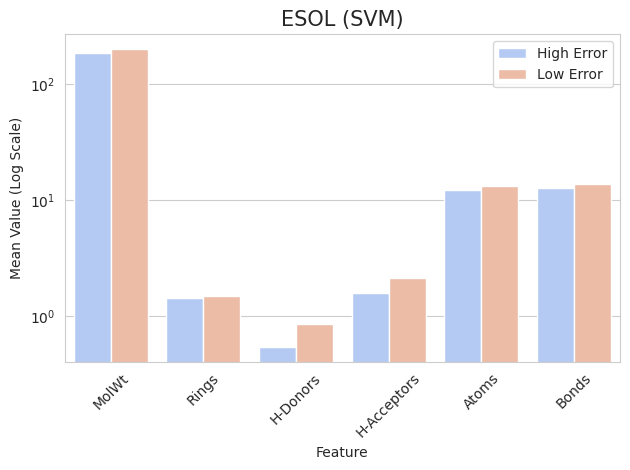

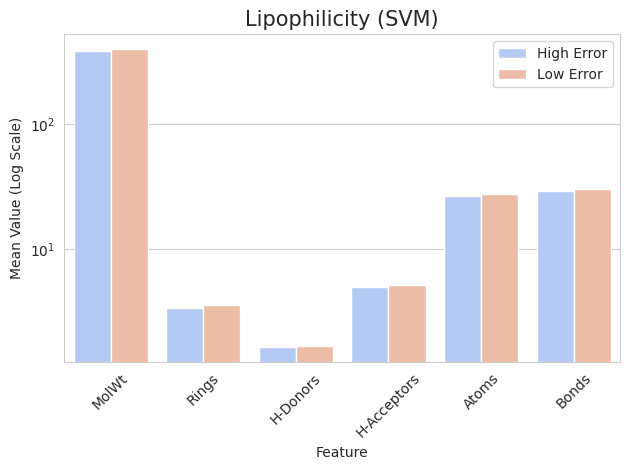

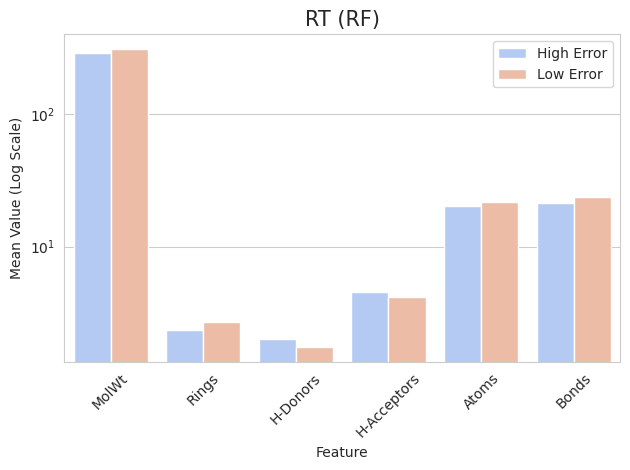

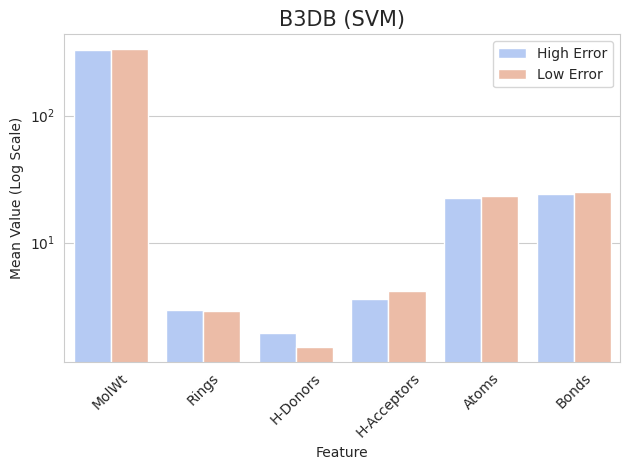

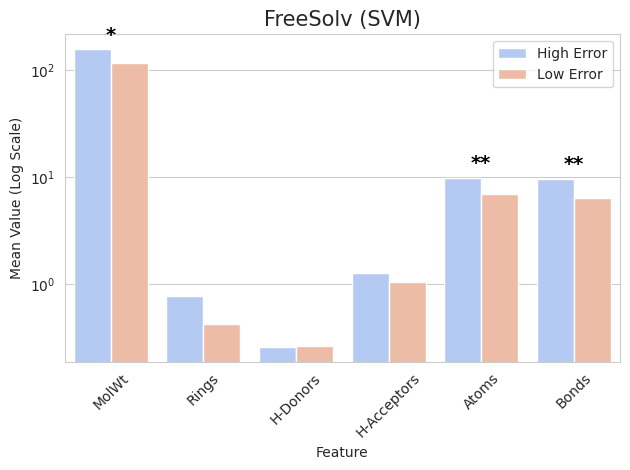

In [6]:
# List to store results
temp_out = []

# Loop for models
for dataName, model in datasets_baseline_error.items():
    # Run Analysis for model and dataset
    threshold, modelName = model
    model = model_dict[modelName]
    data = datasets[dataName]
    params_df = pd.read_csv(f"results/Output_Hyperparameter_Optimization_ML_{dataName}.csv")
    params = eval(params_df[params_df["Model"]== modelName]["Model Params"].to_list()[0])
    model =  model.set_params(**params)
    temp_out.append(RunML(model, data["train"], data["test"], dataName, modelName, threshold))